In [1]:
import os
import time
import math
import requests
import matplotlib.pyplot as plt
from collections import defaultdict
from dataclasses import dataclass
from typing import Dict, List, Iterable, Tuple, Optional

import pandas as pd
from dotenv import load_dotenv
load_dotenv()


True

In [2]:
API_KEY = os.getenv("GRAPH_API_KEY")
SUBGRAPH_ID = "5zvR82QoaXYFyDEKLZ9t6v9adgnptxYpKpSbxtgVENFV"
ENDPOINT = f"https://gateway.thegraph.com/api/{API_KEY}/subgraphs/id/{SUBGRAPH_ID}"

In [4]:
POOL = "0x3416cf6c708da44db2624d63ea0aaef7113527c6".lower()

# ---------------------------
# GraphQL helper
# ---------------------------
def gql(query: str, variables: dict | None = None, timeout: int = 60) -> dict:
    r = requests.post(ENDPOINT, json={"query": query, "variables": variables or {}}, timeout=timeout)
    r.raise_for_status()
    payload = r.json()
    if "errors" in payload:
        raise RuntimeError(payload["errors"])
    return payload["data"]


def latest_indexed_block() -> int:
    q = """query { _meta { block { number } } }"""
    return int(gql(q)["_meta"]["block"]["number"])


# ---------------------------
# (A) Static state at block: positions -> liquidity by owner
# ---------------------------
def fetch_positions_at_block(pool: str, block: int, only_active: bool = True,
                            page_size: int = 1000, sleep_s: float = 0.05) -> List[dict]:
    where_liq = "liquidity_gt: 0" if only_active else ""
    q = f"""
    query($pool: String!, $block: Int!, $first: Int!, $lastId: ID!) {{
      positions(
        first: $first
        orderBy: id
        orderDirection: asc
        where: {{ id_gt: $lastId, pool: $pool, {where_liq} }}
        block: {{ number: $block }}
      ) {{
        id
        owner
        liquidity
        tickLower
        tickUpper
        depositedToken0
        depositedToken1
        withdrawnToken0
        withdrawnToken1
      }}
    }}
    """
    out = []
    last_id = "0x0"
    while True:
        data = gql(q, {"pool": pool, "block": block, "first": page_size, "lastId": last_id})
        batch = data["positions"]
        if not batch:
            break
        out.extend(batch)
        last_id = batch[-1]["id"]
        time.sleep(sleep_s)
    return out


def aggregate_liquidity_by_owner(positions: List[dict]) -> pd.DataFrame:
    agg = defaultdict(int)
    for p in positions:
        agg[p["owner"].lower()] += int(p["liquidity"])
    df = pd.DataFrame({"owner": list(agg.keys()), "liquidity": list(agg.values())})
    df = df.sort_values("liquidity", ascending=False).reset_index(drop=True)
    total = df["liquidity"].sum()
    df["share"] = df["liquidity"] / total if total > 0 else 0.0
    return df


def concentration_metrics(df_owner: pd.DataFrame) -> dict:
    # HHI on shares; Top-k shares
    shares = df_owner["share"].to_numpy()
    hhi = float((shares**2).sum())
    top10_share = float(df_owner.head(10)["share"].sum())
    top50_share = float(df_owner.head(50)["share"].sum())
    top1pct = max(1, int(math.ceil(0.01 * len(df_owner))))
    top1pct_share = float(df_owner.head(top1pct)["share"].sum())
    return {
        "n_owners": int(len(df_owner)),
        "hhi": hhi,
        "top10_share": top10_share,
        "top50_share": top50_share,
        "top1pct_share": top1pct_share,
    }


# ---------------------------
# (B) Dynamic events approximation using PositionSnapshot:
# derive delta_liquidity per position over time window
# ---------------------------
def fetch_position_snapshots(pool: str,
                             start_ts: int,
                             end_ts: int,
                             page_size: int = 1000,
                             sleep_s: float = 0.05) -> List[dict]:
    """
    Pull all snapshots in [start_ts, end_ts] for a pool.
    We paginate by id (orderBy id asc). This is reliable if id is unique & ordered.
    """
    q = """
    query($pool: String!, $first: Int!, $lastId: ID!, $start: Int!, $end: Int!) {
      positionSnapshots(
        first: $first
        orderBy: id
        orderDirection: asc
        where: {
          id_gt: $lastId
          pool: $pool
          timestamp_gte: $start
          timestamp_lte: $end
        }
      ) {
        id
        owner
        pool
        position
        blockNumber
        timestamp
        liquidity
        transaction
      }
    }
    """
    out = []
    last_id = "0x0"
    while True:
        data = gql(q, {"pool": pool, "first": page_size, "lastId": last_id, "start": start_ts, "end": end_ts})
        batch = data["positionSnapshots"]
        if not batch:
            break
        out.extend(batch)
        last_id = batch[-1]["id"]
        time.sleep(sleep_s)
    return out


def snapshots_to_liquidity_deltas(snaps: List[dict]) -> pd.DataFrame:
    """
    For each position, sort snapshots by (timestamp, blockNumber, id) and compute
    delta_liquidity between successive snapshots.
    Positive delta ~ "mint/add", negative delta ~ "burn/remove".
    """
    df = pd.DataFrame(snaps)
    if df.empty:
        return df

    # types
    df["timestamp"] = df["timestamp"].astype(int)
    df["blockNumber"] = df["blockNumber"].astype(int)
    df["liquidity"] = df["liquidity"].astype(int)
    df["owner"] = df["owner"].str.lower()

    df = df.sort_values(["position", "timestamp", "blockNumber", "id"]).reset_index(drop=True)

    # group by position and compute delta
    df["prev_liquidity"] = df.groupby("position")["liquidity"].shift(1)
    df = df.dropna(subset=["prev_liquidity"]).copy()
    df["prev_liquidity"] = df["prev_liquidity"].astype(int)

    df["delta_liquidity"] = df["liquidity"] - df["prev_liquidity"]
    df["event_type"] = df["delta_liquidity"].apply(lambda x: "add" if x > 0 else ("remove" if x < 0 else "noop"))
    df = df[df["delta_liquidity"] != 0].copy()

    # bucket to day (UTC)
    df["day"] = (df["timestamp"] // 86400) * 86400
    return df[["day", "timestamp", "blockNumber", "owner", "position", "delta_liquidity", "event_type", "transaction"]]


def aggregate_deltas_by_owner_day(df_deltas: pd.DataFrame) -> pd.DataFrame:
    if df_deltas is None or df_deltas.empty:
        return pd.DataFrame(columns=["day", "owner", "net_delta_liquidity", "add_liquidity", "remove_liquidity"])

    g = df_deltas.groupby(["day", "owner"])["delta_liquidity"]
    out = g.sum().rename("net_delta_liquidity").reset_index()

    adds = df_deltas[df_deltas["delta_liquidity"] > 0].groupby(["day", "owner"])["delta_liquidity"].sum()
    rems = (-df_deltas[df_deltas["delta_liquidity"] < 0].groupby(["day", "owner"])["delta_liquidity"].sum())

    out = out.merge(adds.rename("add_liquidity"), on=["day", "owner"], how="left")
    out = out.merge(rems.rename("remove_liquidity"), on=["day", "owner"], how="left")
    out[["add_liquidity", "remove_liquidity"]] = out[["add_liquidity", "remove_liquidity"]].fillna(0).astype("int64")

    out = out.sort_values(["day", "net_delta_liquidity"], ascending=[True, False]).reset_index(drop=True)
    return out


# ---------------------------
# (C) Pool daily state (reserves/state proxy)
# ---------------------------
def fetch_pool_day_data(pool: str, start_day_ts: int, end_day_ts: int,
                        page_size: int = 1000, sleep_s: float = 0.05) -> pd.DataFrame:
    """
    Uses poolDayDatas (common in Uniswap v3 subgraphs).
    """
    q = """
    query($pool: String!, $first: Int!, $lastId: ID!, $start: Int!, $end: Int!) {
      poolDayDatas(
        first: $first
        orderBy: id
        orderDirection: asc
        where: {
          id_gt: $lastId
          pool: $pool
          date_gte: $start
          date_lte: $end
        }
      ) {
        id
        date
        liquidity
        sqrtPrice
        tick
        tvlUSD
        volumeUSD
        feesUSD
        tvlToken0
        tvlToken1
      }
    }
    """
    out = []
    last_id = "0x0"
    while True:
        data = gql(q, {"pool": pool, "first": page_size, "lastId": last_id, "start": start_day_ts, "end": end_day_ts})
        batch = data["poolDayDatas"]
        if not batch:
            break
        out.extend(batch)
        last_id = batch[-1]["id"]
        time.sleep(sleep_s)

    df = pd.DataFrame(out)
    if not df.empty:
        df["date"] = df["date"].astype(int)
    return df


# ---------------------------
# Main
# ---------------------------
if __name__ == "__main__":
    block = latest_indexed_block()
    print("Latest indexed block:", block)

    # ---- A) Static concentration at latest block ----
    positions = fetch_positions_at_block(POOL, block, only_active=True)
    df_owner = aggregate_liquidity_by_owner(positions)
    metrics = concentration_metrics(df_owner)
    print("Static metrics:", metrics)

    df_owner.to_csv("usdc_usdt_v3_lp_liquidity_by_owner_latest_block.csv", index=False)

    # ---- B) Dynamic: snapshot-derived flows over a time window ----
    # Choose your window (example: last 30 days from now-ish; you should set exact timestamps)
    # Here we set a fixed example window; replace with your own.
    END_TS = int(time.time())
    START_TS = END_TS - 30 * 86400

    snaps = fetch_position_snapshots(POOL, START_TS, END_TS)  
    

Latest indexed block: 24582973
Static metrics: {'n_owners': 560, 'hhi': 0.06652043816626634, 'top10_share': 0.641321113247962, 'top50_share': 0.9540112363164758, 'top1pct_share': 0.5560381034601147}


In [8]:
fetch_position_snapshots(POOL, START_TS, END_TS, page_size=1000, sleep_s=0.05)

[{'blockNumber': '24398353',
  'id': '1025221#24398353',
  'liquidity': '0',
  'owner': '0x64795621060ce7f2e0e20f7d7e23788a02ab82ba',
  'timestamp': '1770387779'},
 {'blockNumber': '24412937',
  'id': '1049334#24412937',
  'liquidity': '0',
  'owner': '0xeac8919da35e0392378cd4b52aedb85f54e34fbb',
  'timestamp': '1770564335'},
 {'blockNumber': '24400991',
  'id': '1085581#24400991',
  'liquidity': '72971738997',
  'owner': '0x97783ee3fa08b8950b4ac3c8a5c0d672d1bc0348',
  'timestamp': '1770419603'},
 {'blockNumber': '24400995',
  'id': '1085581#24400995',
  'liquidity': '0',
  'owner': '0x97783ee3fa08b8950b4ac3c8a5c0d672d1bc0348',
  'timestamp': '1770419651'},
 {'blockNumber': '24404073',
  'id': '1095607#24404073',
  'liquidity': '0',
  'owner': '0xa582020a6fbd768fed222c8e93236640c371fb58',
  'timestamp': '1770456803'},
 {'blockNumber': '24406769',
  'id': '1131428#24406769',
  'liquidity': '0',
  'owner': '0xe01a27922e0b4bd874c8b03bfdb143ee7bce268b',
  'timestamp': '1770489311'},
 {'blo

In [6]:
def snapshots_to_liquidity_deltas(snaps: list[dict]) -> pd.DataFrame:
    df = pd.DataFrame(snaps)
    if df.empty:
        return pd.DataFrame(columns=[
            "day","timestamp","blockNumber","owner","position_id",
            "liquidity","prev_liquidity","delta_liquidity","event_type"
        ])

    # types
    df["timestamp"] = df["timestamp"].astype(int)
    df["blockNumber"] = df["blockNumber"].astype(int)
    df["liquidity"] = df["liquidity"].astype(int)
    df["owner"] = df["owner"].str.lower()

    # position id is encoded in snapshot id: "{positionId}#{blockNumber}"
    df["position_id"] = df["id"].astype(str).str.split("#").str[0]

    # sort within each position
    df = df.sort_values(["position_id", "blockNumber", "id"]).reset_index(drop=True)

    # delta per position
    df["prev_liquidity"] = df.groupby("position_id")["liquidity"].shift(1)
    df = df.dropna(subset=["prev_liquidity"]).copy()
    df["prev_liquidity"] = df["prev_liquidity"].astype(int)

    df["delta_liquidity"] = df["liquidity"] - df["prev_liquidity"]
    df = df[df["delta_liquidity"] != 0].copy()

    df["event_type"] = df["delta_liquidity"].apply(lambda x: "add" if x > 0 else "remove")
    df["day"] = (df["timestamp"] // 86400) * 86400

    return df[[
        "day","timestamp","blockNumber","owner","position_id",
        "liquidity","prev_liquidity","delta_liquidity","event_type"
    ]]

In [18]:
snaps_df = snapshots_to_liquidity_deltas(snaps)

In [19]:
def aggregate_deltas_by_owner_day(df_deltas: pd.DataFrame) -> pd.DataFrame:
    if df_deltas.empty:
        return pd.DataFrame(columns=["day","owner","net_delta_liquidity","add_liquidity","remove_liquidity"])

    out = (df_deltas
           .groupby(["day","owner"])["delta_liquidity"]
           .sum()
           .rename("net_delta_liquidity")
           .reset_index())

    adds = (df_deltas[df_deltas["delta_liquidity"] > 0]
            .groupby(["day","owner"])["delta_liquidity"].sum()
            .rename("add_liquidity"))

    rems = (-df_deltas[df_deltas["delta_liquidity"] < 0]
            .groupby(["day","owner"])["delta_liquidity"].sum()
            .rename("remove_liquidity"))

    out = out.merge(adds, on=["day","owner"], how="left").merge(rems, on=["day","owner"], how="left")
    out[["add_liquidity","remove_liquidity"]] = out[["add_liquidity","remove_liquidity"]].fillna(0).astype("int64")
    return out.sort_values(["day","net_delta_liquidity"], ascending=[True, False]).reset_index(drop=True)

In [9]:
from decimal import Decimal, getcontext
from collections import defaultdict


getcontext().prec = 50  # safe for token amounts

POOL = "0x3416cf6c708da44db2624d63ea0aaef7113527c6".lower()


def gql(query: str, variables: dict | None = None, timeout=60) -> dict:
    r = requests.post(ENDPOINT, json={"query": query, "variables": variables or {}}, timeout=timeout)
    r.raise_for_status()
    payload = r.json()
    if "errors" in payload:
        raise RuntimeError(payload["errors"])
    return payload["data"]


def latest_indexed_block() -> int:
    q = "query { _meta { block { number } } }"
    return int(gql(q)["_meta"]["block"]["number"])


def fetch_pool_tokens(pool: str) -> dict:
    # Optional (nice for labeling). If this errors, just skip calling it.
    q = """
    query($pool: ID!) {
      pool(id: $pool) {
        id
        token0 { id symbol decimals }
        token1 { id symbol decimals }
        feeTier
      }
    }
    """
    return gql(q, {"pool": pool})["pool"]


def fetch_active_positions_at_block(pool: str, block: int, page_size: int = 1000, sleep_s: float = 0.05):
    q = """
    query($pool: String!, $block: Int!, $first: Int!, $lastId: ID!) {
      positions(
        first: $first
        orderBy: id
        orderDirection: asc
        where: {
          id_gt: $lastId
          pool: $pool
          liquidity_gt: 0
        }
        block: { number: $block }
      ) {
        id
        owner
        liquidity
        depositedToken0
        depositedToken1
        withdrawnToken0
        withdrawnToken1
      }
    }
    """
    out = []
    last_id = "0"
    while True:
        data = gql(q, {"pool": pool, "block": block, "first": page_size, "lastId": last_id})
        batch = data["positions"]
        if not batch:
            break
        out.extend(batch)
        last_id = batch[-1]["id"]
        time.sleep(sleep_s)
    return out


def _D(x) -> Decimal:
    # Graph returns strings; Decimal handles them precisely
    return Decimal(str(x))


def aggregate_by_owner(positions: list[dict]) -> pd.DataFrame:
    agg = defaultdict(lambda: {
        "liq_L": 0,
        "net_token0": Decimal(0),
        "net_token1": Decimal(0),
        "n_positions": 0
    })

    for p in positions:
        owner = p["owner"].lower()
        a = agg[owner]
        a["n_positions"] += 1
        a["liq_L"] += int(p["liquidity"])

        net0 = _D(p["depositedToken0"]) - _D(p["withdrawnToken0"])
        net1 = _D(p["depositedToken1"]) - _D(p["withdrawnToken1"])
        a["net_token0"] += net0
        a["net_token1"] += net1

    rows = []
    for owner, a in agg.items():
        # For USDC/USDT, approx USD not terrible: 1 USDC ~ 1 USD, 1 USDT ~ 1 USD
        approx_usd = a["net_token0"] + a["net_token1"]
        rows.append({
            "owner": owner,
            "n_positions": a["n_positions"],
            "liq_L": a["liq_L"],
            "net_token0": str(a["net_token0"]),
            "net_token1": str(a["net_token1"]),
            "approx_usd": str(approx_usd),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    # Convert approx_usd to numeric for sorting/metrics
    df["approx_usd_num"] = df["approx_usd"].map(Decimal)

    df = df.sort_values("approx_usd_num", ascending=False).reset_index(drop=True)

    total_usd = sum(df["approx_usd_num"])
    total_L = df["liq_L"].sum()

    df["share_usd"] = df["approx_usd_num"].apply(lambda x: float(x / total_usd) if total_usd != 0 else 0.0)
    df["share_L"] = df["liq_L"].apply(lambda x: (x / total_L) if total_L != 0 else 0.0)
    return df


def gini_from_shares(shares: list[float]) -> float:
    # shares should be nonnegative and sum to 1 (approximately)
    xs = sorted(shares)
    n = len(xs)
    if n == 0:
        return float("nan")
    cum = 0.0
    for i, x in enumerate(xs, 1):
        cum += i * x
    return (2.0 * cum) / n - (n + 1.0) / n


def concentration_report(df: pd.DataFrame, share_col: str) -> dict:
    shares = df[share_col].to_numpy()
    hhi = float((shares ** 2).sum())
    top10 = float(df.head(10)[share_col].sum())
    top50 = float(df.head(50)[share_col].sum())
    top100 = float(df.head(100)[share_col].sum())
    gini = gini_from_shares(shares.tolist())
    return {
        "n_owners": int(len(df)),
        "hhi": hhi,
        "top10_share": top10,
        "top50_share": top50,
        "top100_share": top100,
        "gini": gini
    }


if __name__ == "__main__":
    block = latest_indexed_block()
    print("Latest indexed block:", block)

    # Optional metadata
    try:
        meta = fetch_pool_tokens(POOL)
        print("Pool:", meta["id"], meta["token0"]["symbol"], "/", meta["token1"]["symbol"], "feeTier", meta["feeTier"])
    except Exception as e:
        print("Pool metadata query failed (ok):", e)

    positions = fetch_active_positions_at_block(POOL, block)
    print("Active positions fetched:", len(positions))

    df = aggregate_by_owner(positions)
    print("Unique owners:", len(df))

    # Reports
    print("Concentration by approx USD:")
    print(concentration_report(df, "share_usd"))
    print("Concentration by v3 liquidity L:")
    print(concentration_report(df, "share_L"))

    # Save
    df.to_csv("usdc_usdt_v3_owner_concentration_latest_block.csv", index=False)

    # Also save top owners table
    df.head(200).to_csv("usdc_usdt_v3_owner_top200_latest_block.csv", index=False)

Latest indexed block: 24583005
Pool: 0x3416cf6c708da44db2624d63ea0aaef7113527c6 USDC / USDT feeTier 100
Active positions fetched: 708
Unique owners: 560
Concentration by approx USD:
{'n_owners': 560, 'hhi': 0.08913596158379608, 'top10_share': 0.6239497942005937, 'top50_share': 0.8841258283915325, 'top100_share': 0.9846680142080904, 'gini': 0.9383106547423243}
Concentration by v3 liquidity L:
{'n_owners': 560, 'hhi': 0.06652043816626632, 'top10_share': 0.5285865115234852, 'top50_share': 0.9106539967686333, 'top100_share': 0.9947314443737928, 'gini': 0.950639198579335}


In [10]:
df

,owner,n_positions,liq_L,net_token0,net_token1,approx_usd,approx_usd_num,share_usd,share_L
0,0xe463bc0239da279254ebde06b2e8f2ab20f1de30,2,6375589724761029,2064295.075245,2052398.464314,4116693.539559,4116693.539559,2.251102e-01,1.084594e-01
1,0x84357c03321b49e5b5414bc710dd80f71ddd874b,2,10248419719274601,1301728.080873,1772513.045424,3074241.126297,3074241.126297,1.681065e-01,1.743428e-01
2,0x9680611acef47b37dcfb2bc597100ae57be67cf8,1,39313182237368,704066.897028,399987.045465,1104053.942493,1104053.942493,6.037220e-02,6.687829e-04
3,0x033fccf5755cfb07856f699677411b7ea4e49cc7,1,213025742309305,209323.280795,418612.420126,627935.700921,627935.700921,3.433696e-02,3.623924e-03
4,0x0cbe5561012c92564a21b484afee8f3d68eb2db5,2,5415850645944153,540326.458419,1204.332651,541530.791070,541530.791070,2.961214e-02,9.213267e-02
...,...,...,...,...,...,...,...,...,...
555,0x6b9ea60821bd0214a6e63ca848869528d5a554f9,1,961778,0.000093,0.0001,0.000193,0.000193,1.055368e-11,1.636145e-11
556,0x929c3daf2e2be4c74a56ec01df374bc46a34c6a1,1,187956,0.000089,0.000099,0.000188,0.000188,1.028027e-11,3.197446e-12
557,0x564bf7d4a35603a5e5cee8f0ff14086f67374b9f,1,14284,0.000007,0.000008,0.000015,0.000015,8.202344e-13,2.429947e-13
558,0x45d1f278a733b3832a73af9724b1491c336befab,1,98105008,0.000001,0,0.000001,0.000001,5.468229e-14,1.668930e-09


In [11]:
hourly_blocks = pd.read_parquet('data/ETH_blocks/hourly_blocks.parquet')
hourly_blocks = hourly_blocks.rename(columns = {"hour_utc": "hour", 'block_number': "block"})
hourly_pool_state = pd.read_parquet('data/Uniswap/hourly_pool_state_full.parquet')
hourly_curve = pd.read_parquet('./data/Uniswap/hourly_liquidity_full.parquet')

In [12]:
import time
import math
import requests
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm


# -----------------------------
# 0) GraphQL plumbing
# -----------------------------
def gql(endpoint: str, query: str, variables: dict | None = None, timeout: int = 60) -> dict:
    r = requests.post(endpoint, json={"query": query, "variables": variables or {}}, timeout=timeout)
    r.raise_for_status()
    payload = r.json()
    if "errors" in payload:
        raise RuntimeError(payload["errors"])
    return payload["data"]


def fetch_positions_at_block(
    endpoint: str,
    pool: str,
    block: int,
    page_size: int = 1000,
    sleep_s: float = 0.05,
    include_ticks: bool = True,
) -> pd.DataFrame:
    """
    Pull all positions for `pool` at a given `block`.
    If include_ticks=True, also request tickLower/tickUpper to compute 'effective' (in-range) concentration.
    """
    pool = pool.lower()

    if include_ticks:
        # common Uniswap v3 schema
        tick_fields = """
          tickLower { tickIdx }
          tickUpper { tickIdx }
        """
    else:
        tick_fields = ""

    q = f"""
    query($pool: String!, $block: Int!, $first: Int!, $lastId: ID!) {{
      positions(
        first: $first
        orderBy: id
        orderDirection: asc
        where: {{
          id_gt: $lastId
          pool: $pool
          liquidity_gt: 0
        }}
        block: {{ number: $block }}
      ) {{
        id
        owner
        liquidity
        {tick_fields}
      }}
    }}
    """

    out = []
    last_id = "0"
    while True:
        data = gql(endpoint, q, {"pool": pool, "block": int(block), "first": int(page_size), "lastId": last_id})
        batch = data["positions"]
        if not batch:
            break
        out.extend(batch)
        last_id = batch[-1]["id"]
        time.sleep(sleep_s)

    if not out:
        return pd.DataFrame(columns=["id", "owner", "liquidity", "tickLower", "tickUpper"])

    df = pd.DataFrame(out)
    df["owner"] = df["owner"].str.lower()
    df["liquidity"] = df["liquidity"].astype(np.int64)

    if include_ticks and "tickLower" in df.columns and "tickUpper" in df.columns:
        # tickLower / tickUpper are nested dicts like {"tickIdx": "..."}
        df["tickLower"] = df["tickLower"].apply(lambda x: int(x["tickIdx"]) if isinstance(x, dict) and "tickIdx" in x else np.nan)
        df["tickUpper"] = df["tickUpper"].apply(lambda x: int(x["tickIdx"]) if isinstance(x, dict) and "tickIdx" in x else np.nan)
    else:
        df["tickLower"] = np.nan
        df["tickUpper"] = np.nan

    return df


# -----------------------------
# 1) Concentration metrics
# -----------------------------
def hhi_from_owner_liquidity(owner_liq: pd.Series) -> float:
    """
    owner_liq: Series indexed by owner, values >=0
    """
    total = owner_liq.sum()
    if total <= 0:
        return np.nan
    shares = (owner_liq / total).to_numpy(dtype=np.float64)
    return float(np.sum(shares * shares))


def topk_share(owner_liq: pd.Series, k: int) -> float:
    total = owner_liq.sum()
    if total <= 0:
        return np.nan
    return float(owner_liq.sort_values(ascending=False).head(k).sum() / total)


def effective_n_from_hhi(hhi: float) -> float:
    return (1.0 / hhi) if (hhi is not None and np.isfinite(hhi) and hhi > 0) else np.nan


def outflow_share_from_prev_top10(prev_owner_liq: pd.Series, curr_owner_liq: pd.Series) -> float:
    """
    Outflow share attributable to the *previous-hour* top-10 owners.

    Define per-owner outflow = max(0, L_prev - L_curr).
    Total outflow = sum outflow across all owners.
    Numerator = sum outflow for owners in top10(prev).
    """
    if prev_owner_liq is None or curr_owner_liq is None or len(prev_owner_liq) == 0:
        return np.nan

    # align
    all_owners = prev_owner_liq.index.union(curr_owner_liq.index)
    prev = prev_owner_liq.reindex(all_owners).fillna(0).astype(np.int64)
    curr = curr_owner_liq.reindex(all_owners).fillna(0).astype(np.int64)

    outflow = (prev - curr).clip(lower=0)
    total_outflow = outflow.sum()
    if total_outflow <= 0:
        return 0.0  # no outflow in this hour

    top10_prev = prev.sort_values(ascending=False).head(10).index
    return float(outflow.reindex(top10_prev).sum() / total_outflow)


def owner_liquidity_from_positions(df_pos: pd.DataFrame) -> pd.Series:
    return df_pos.groupby("owner")["liquidity"].sum()


def owner_liquidity_effective_active(df_pos: pd.DataFrame, pool_tick: int) -> pd.Series:
    """
    "Effective" active positions at time t: positions whose [tickLower, tickUpper) contains pool_tick.
    This is the v3 notion of being in-range.
    """
    if df_pos.empty:
        return pd.Series(dtype=np.int64)

    if df_pos["tickLower"].isna().all() or df_pos["tickUpper"].isna().all():
        # ticks not available => cannot compute effective range
        return pd.Series(dtype=np.int64)

    in_range = (df_pos["tickLower"] <= pool_tick) & (pool_tick < df_pos["tickUpper"])
    df_eff = df_pos.loc[in_range]
    if df_eff.empty:
        return pd.Series(dtype=np.int64)
    return df_eff.groupby("owner")["liquidity"].sum()


# -----------------------------
# 2) Main: compute hourly feature table
# -----------------------------
def compute_hourly_lp_concentration_features(
    hourly_blocks: pd.DataFrame,
    hourly_pool_state: pd.DataFrame,
    endpoint: str,
    pool: str,
    include_ticks: bool = True,
    sleep_s: float = 0.05,
) -> pd.DataFrame:
    """
    hourly_blocks: columns ['hour'(datetime64[ns,UTC] or iso), 'block'(int)]
    hourly_pool_state: columns ['hour', 'poolTick'(int)]
    """
    df = hourly_blocks.merge(hourly_pool_state[["hour", "poolTick"]], on="hour", how="left")
    df = df.sort_values("hour").reset_index(drop=True)

    rows = []
    prev_owner_liq = None
    prev_owner_liq_eff = None

    for _, r in tqdm(df.iterrows(), total=len(df)):
        hour = r["hour"]
        block = int(r["block"])
        pool_tick = int(r["poolTick"]) if pd.notna(r["poolTick"]) else None

        # pull positions at this block
        try:
            pos = fetch_positions_at_block(
                endpoint=endpoint,
                pool=pool,
                block=block,
                sleep_s=sleep_s,
                include_ticks=include_ticks,
            )
        except RuntimeError as e:
            # If schema doesn't have tickLower/tickUpper, retry without ticks
            if include_ticks and ("tickLower" in str(e) or "tickUpper" in str(e)):
                pos = fetch_positions_at_block(endpoint, pool, block, sleep_s=sleep_s, include_ticks=False)
            else:
                raise

        owner_liq = owner_liquidity_from_positions(pos)

        # effective (in-range) only
        if pool_tick is not None:
            owner_liq_eff = owner_liquidity_effective_active(pos, pool_tick)
        else:
            owner_liq_eff = pd.Series(dtype=np.int64)

        # concentration at time t
        hhi = hhi_from_owner_liquidity(owner_liq)
        hhi_eff = hhi_from_owner_liquidity(owner_liq_eff)

        row = {
            "hour": hour,
            "block": block,
            "poolTick": pool_tick,

            # totals
            "total_L": int(owner_liq.sum()) if len(owner_liq) else 0,
            "hhi": hhi,
            "n_eff": effective_n_from_hhi(hhi),
            "top1_share": topk_share(owner_liq, 1),
            "top5_share": topk_share(owner_liq, 5),
            "top10_share": topk_share(owner_liq, 10),
            "top20_share": topk_share(owner_liq, 20),

            # effective (in-range) only
            "total_L_effective": int(owner_liq_eff.sum()) if len(owner_liq_eff) else 0,
            "hhi_effective": hhi_eff,
            "n_eff_effective": effective_n_from_hhi(hhi_eff),
            "top10_share_effective": topk_share(owner_liq_eff, 10) if len(owner_liq_eff) else np.nan,
        }

        # dynamic feature: outflow share from previous top-10
        if prev_owner_liq is None:
            row["outflow_share_prev_top10"] = np.nan
        else:
            row["outflow_share_prev_top10"] = outflow_share_from_prev_top10(prev_owner_liq, owner_liq)

        # dynamic feature on effective in-range liquidity
        if prev_owner_liq_eff is None:
            row["outflow_share_prev_top10_effective"] = np.nan
        else:
            row["outflow_share_prev_top10_effective"] = outflow_share_from_prev_top10(prev_owner_liq_eff, owner_liq_eff)

        rows.append(row)

        prev_owner_liq = owner_liq
        prev_owner_liq_eff = owner_liq_eff

    return pd.DataFrame(rows), owner_liq, owner_liq_eff, pos



In [13]:
df_features, owner_liq, owner_liq_eff, pos =compute_hourly_lp_concentration_features(
    hourly_blocks=hourly_blocks.iloc[-2:-1],
    hourly_pool_state=hourly_pool_state[-2:],
    endpoint=ENDPOINT,
    pool="0x3416cf6c708da44db2624d63ea0aaef7113527c6",
    include_ticks=True,
    sleep_s=0.001,
)
# fff, owner_liq_prev, owner_liq_eff_prev, pos_prev =compute_hourly_lp_concentration_features(
#     hourly_blocks=hourly_blocks.iloc[-3:-2],
#     hourly_pool_state=hourly_pool_state[-3:],
#     endpoint=ENDPOINT,
#     pool="0x3416cf6c708da44db2624d63ea0aaef7113527c6",
#     include_ticks=True,
#     sleep_s=0.001,
# )

  0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
pos

,id,liquidity,owner,tickLower,tickUpper
0,1007941,5000946,0x77777cc68b333a2256b436d675e8d257699aa667,-887272,887272
1,1009502,998,0xb9a10fa58625d8d51d9a049d8933545ce5ff1f7f,-887272,887272
2,1009727,47512194066,0xa1157f4d219a3951eb7b6828822e8994aa11c0ee,-22,18
3,1013363,998,0xb9a10fa58625d8d51d9a049d8933545ce5ff1f7f,-887272,887272
4,1024316,98105008,0x45d1f278a733b3832a73af9724b1491c336befab,197694,197698
...,...,...,...,...,...
705,983180,87056369774,0xad644a1ea3fbdea397a20cd19d79eae1a04b6dec,-3,2
706,995135,15089386249,0xb7c9929526d966c1722b2c1b5b16b8b26d963296,-14,9
707,995168,1000073711,0x3308f8fb2c640b0d70bbd1ccfa3272ef78ced4d5,-887272,887272
708,995352,7148504746,0x2a0ab86648d5e5d52e8e155177d744f210500a12,-887272,887272


/tmp/ipykernel_4183/1666952675.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(pos2))


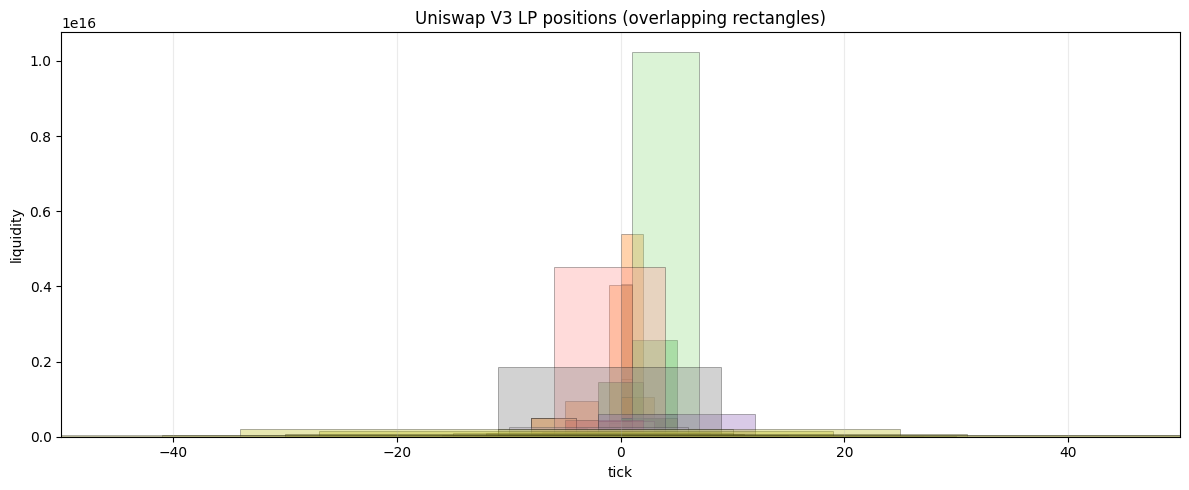

In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.cm as cm
import numpy as np

pos2 = pos.copy()
pos2["width"] = pos2["tickUpper"] - pos2["tickLower"]
pos2 = pos2.sort_values("width", ascending=True)  # narrow -> wide

fig, ax = plt.subplots(figsize=(12, 5))

# one distinct color per position
cmap = cm.get_cmap("tab20", len(pos2))

for i, (_, r) in enumerate(pos2.iterrows()):
    x0 = float(r["tickLower"])
    w  = float(r["width"])
    h  = float(r["liquidity"])

    ax.add_patch(Rectangle((x0, 0.0), w, h,  # all start at y=0 (overlap)
                           facecolor=cmap(i),
                           edgecolor="k",
                           alpha=0.35, lw=0.6))

ax.set_xlabel("tick")
ax.set_ylabel("liquidity")
ax.set_title("Uniswap V3 LP positions (overlapping rectangles)")

ax.set_xlim(-50, 50)
ax.set_ylim(0, pos2["liquidity"].max() * 1.05)
ax.grid(True, axis="x", alpha=0.25)

plt.tight_layout()
plt.show()